In [ ]:
import numpy as np
from matplotlib import pyplot as plt
import ctypes
from ctypes import c_int64, c_int, c_double, c_void_p, byref, POINTER, Structure, c_longlong

FIXED_FRAME_SIZE = int(268000)
class PicamCameraID(ctypes.Structure):
    _fields_ = [
        ("model", c_int),
        ("computer_interface", c_int),
        ("sensor_name", ctypes.c_char * 64),
        ("serial_number", ctypes.c_char * 64),
    ]


class PicamAcquisitionErrorsMask(Structure):
    _fields_ = [("mask", c_int)]


class PicamReadout(ctypes.Structure):
    _fields_ = [
        
        ("frame_size", c_int),  # Size of the data frame
        ("data", POINTER(ctypes.c_int64)),  # Pointer to the readout data
    ]


class PicamAvailableData(Structure):
    _fields_ = [("initial_readout", c_void_p), ("readout_count", c_longlong)]


class SpectrometerController:
    def __init__(self, library_path):
        """
        Initialize the spectrometer controller.

        :param library_path: Path to the PICam shared library (DLL or .so file).
        """
        self.dll = ctypes.cdll.LoadLibrary(library_path)
        self.camera_handle = c_void_p()

    def check_error(self, error_code):
        """
        Check and raise an exception if the error code is not PicamError_None.

        :param error_code: Error code returned by a PICam function.
        """
        if error_code != 0:  # PicamError_None = 0
            raise Exception(f"PICam Error {error_code}: {self.get_error_string(error_code)}")

    def get_error_string(self, error_code):
        """
        Get a string description of the given error code.

        :param error_code: Error code returned by a PICam function.
        :return: Description of the error.
        """
        self.dll.Picam_GetEnumerationString.restype = ctypes.POINTER(ctypes.c_char_p)
        error_string = ctypes.c_char_p()
        self.dll.Picam_GetEnumerationString(c_int(1), error_code, byref(error_string))  # 1 = PicamEnumeratedType_Error
        return error_string.value.decode()

    def initialize(self):
        """Initialize the PICam library."""
        self.check_error(self.dll.Picam_InitializeLibrary())

    def uninitialize(self):
        """Uninitialize the PICam library."""
        self.check_error(self.dll.Picam_UninitializeLibrary())

    def open_camera(self, camera_id):
        """
        Open a specific camera by its ID.

        :param camera_id: An instance of PicamCameraID.
        """
        self.check_error(self.dll.Picam_OpenCamera(byref(camera_id), byref(self.camera_handle)))

    def close_camera(self):
        """Close the currently opened camera."""
        self.check_error(self.dll.Picam_CloseCamera(self.camera_handle))
        self.camera_handle = None


    def acquire_data(self, readout_count=1, timeout_ms=1000):
        """
        Acquire data from the spectrometer and ensure frame size matches the requirement.

        :param required_frame_size: Expected frame size for the acquisition.
        :param readout_count: Number of readouts to acquire.
        :param timeout_ms: Timeout in milliseconds for acquisition.
        :return: List of processed frames.
        """
        available_data = PicamAvailableData()
        errors = PicamAcquisitionErrorsMask()


        self.check_error(
            self.dll.Picam_Acquire(
                self.camera_handle,
                c_int(readout_count),
                c_int(timeout_ms),
                byref(available_data),
                byref(errors),
            )
        )

        return self.process_available_data(available_data)
    def start_acquisition(self):
        """
        Start data acquisition.
        """
        self.check_error(self.dll.Picam_StartAcquisition(self.camera_handle))

    def stop_acquisition(self):
        """
        Stop data acquisition.
        """
        self.check_error(self.dll.Picam_StopAcquisition(self.camera_handle))

    def is_acquisition_running(self):
        """
        Check if acquisition is running.

        :return: True if acquisition is running, False otherwise.
        """
        running = c_int()
        self.check_error(self.dll.Picam_IsAcquisitionRunning(self.camera_handle, byref(running)))
        return bool(running.value)
    def list_cameras(self):
        """
        List available cameras.

        :return: List of PicamCameraID instances.
        """
        camera_ids = POINTER(PicamCameraID)()
        camera_count = c_int()
        self.check_error(self.dll.Picam_GetAvailableCameraIDs(byref(camera_ids), byref(camera_count)))

        cameras = []
        for i in range(camera_count.value):
            cameras.append(camera_ids[i])

        self.dll.Picam_DestroyCameraIDs(camera_ids)
        return cameras
        
    def process_available_data(self, available_data):
        """
        Process the available data from the acquisition.

        :param readouts: Array of PicamReadout structures.
        :param readout_count: Number of readouts to process.
        :return: List of processed frames.
        """
        processed_frames = []
        for i in range(available_data.readout_count):
            readout = readouts[i]
            frame = (c_int64 * FIXED_FRAME_SIZE).from_address(ctypes.addressof(readout.data.contents))
            dataArrayType = ctypes.c_uint16 * int(FIXED_FRAME_SIZE) #readoutstride
            dataArrayPointerType = ctypes.POINTER(dataArrayType)
            dataPointer = ctypes.cast(available_data.initial_readout, dataArrayPointerType)
            
            processed_frames.append(list(frame))  # Convert to a Python list
        return processed_frames

    def set_parameter(self, parameter, value):
        """
        Set a camera parameter.

        :param parameter: Parameter ID to set.
        :param value: Value to set for the parameter.
        """
        if isinstance(value, int):
            self.check_error(self.dll.Picam_SetParameterIntegerValue(self.camera_handle, parameter, c_int(value)))
        elif isinstance(value, float):
            self.check_error(self.dll.Picam_SetParameterFloatingPointValue(self.camera_handle, parameter, c_double(value)))
        else:
            raise TypeError("Unsupported parameter value type. Must be int or float.")

    def get_parameter(self, parameter):
        """
        Get the value of a camera parameter.

        :param parameter: Parameter ID to retrieve.
        :return: Value of the parameter.
        """
        value = c_double()
        self.check_error(self.dll.Picam_GetParameterFloatingPointValue(self.camera_handle, parameter, byref(value)))
        return value.value


from ctypes import POINTER, c_long, c_int, byref

class CameraParameterManager:
    def __init__(self, controller):
        """
        Initializes the CameraParameterManager with the provided controller.
        
        :param controller: The SpectrometerController instance with DLL and camera handle.
        """
        self.controller = controller
        self.parameters = {}
        self.parameter_count = 0

    def load_parameters(self):
        """
        Loads all supported parameters for the connected camera.
        """
        parameter_count = c_int()
        parameters = POINTER(c_long)()

        # Call the Picam_GetParameters function
        error_code = self.controller.dll.Picam_GetParameters(
            self.controller.camera_handle,
            byref(parameters),
            byref(parameter_count)
        )
        self.controller.check_error(error_code)

        # Save parameters to a dictionary mapping ID to function number
        self.parameters = {
            parameters[i]: self.get_function_number(parameters[i])
            for i in range(parameter_count.value)
        }
        self.parameter_count = parameter_count.value
        print("Loaded parameters successfully.")

    @staticmethod
    def get_function_number(parameter_id):
        """
        Extracts the function number (n) from a PicamParameter ID.

        :param parameter_id: The parameter ID as an integer (hexadecimal value in numeric form).
        :return: The function number (n).
        """
        return parameter_id & 0xFFFF  # Mask the lower 16 bits

    def is_parameter_supported(self, parameter_id):
        """
        Checks if a specific parameter is supported by the camera.

        :param parameter_id: The parameter ID to check.
        :return: True if the parameter is supported, False otherwise.
        """
        return parameter_id in self.parameters

    def query_parameter(self, parameter_id):
        """
        Queries the camera for a specific parameter and prints its function number if supported.

        :param parameter_id: The parameter ID to query.
        :return: The function number if supported, or a message if not.
        """
        if self.is_parameter_supported(parameter_id):
            return f"Parameter ID: {hex(parameter_id)} is supported. Function Number: {self.parameters[parameter_id]}"
        else:
            return f"Parameter ID: {hex(parameter_id)} is not supported by the camera."

    def print_all_parameters(self):
        """
        Prints all available parameters and their function numbers.
        """
        print("Supported Parameters and Function Numbers:")
        for param_id, func_num in self.parameters.items():
            print(f"Parameter ID: {hex(param_id)}, Function Number: {func_num}")

    picam_parameters = {
    42: "Frame Size",
    43: "Frame Stride",
    44: "Frames Per Readout",
    45: "Readout Stride",
    48: "Pixel Bit Depth",
    49: "Sensor Secondary Masked Height",
    59: "Sensor Active Width",
    60: "Sensor Active Height",
    61: "Sensor Active Left Margin",
    62: "Sensor Active Top Margin",
    63: "Sensor Active Right Margin",
    64: "Sensor Active Bottom Margin",
    65: "Sensor Masked Height",
    66: "Sensor Masked Top Margin",
    67: "Sensor Masked Bottom Margin",
    74: "Sensor Secondary Active Height",
    159: "Sensor Active Extended Height",
    9: "Pixel Width",
    10: "Pixel Height",
    11: "Pixel Gap Width",
    12: "Pixel Gap Height",
    15: "Sensor Temperature Reading",
    27: "Readout Time Calculation",
    50: "Readout Rate Calculation",
    51: "Frame Rate Calculation",
    99: "Online Readout Rate Calculation",
    16: "Sensor Temperature Status",
    38: "Orientation",
    54: "Readout Orientation",
    57: "Sensor Type",
    58: "CCD Characteristics",
    77: "Exact Readout Count Maximum",
    1: "Active Width",
    2: "Active Height",
    3: "Active Left Margin",
    4: "Active Top Margin",
    5: "Active Right Margin",
    6: "Active Bottom Margin",
    17: "Clean Section Final Height",
    18: "Clean Section Final Height Count",
    20: "Clean Cycle Count",
    21: "Clean Cycle Height",
    56: "Kinetics Window Height",
    14: "Sensor Temperature Set Point",
    23: "Exposure Time",
    25: "Shutter Closing Delay",
    40: "Readout Count",
    34: "ADC Bit Depth",
    70: "Timestamp Bit Depth",
    72: "Frame Tracking Bit Depth",
    13: "Vertical Shift Rate",
    33: "ADC Speed",
    47: "Shutter Delay Resolution",
    19: "Clean Serial Register",
    22: "Clean Until Trigger",
    39: "Normalize Orientation",
    55: "Disable Data Formatting",
    71: "Track Frames",
    24: "Shutter Timing Mode",
    26: "Readout Control Mode",
    30: "Trigger Response",
    31: "Trigger Determination",
    32: "Output Signal",
    35: "ADC Analog Gain",
    36: "ADC Quality",
    41: "Pixel Format",
    68: "Timestamp Modes",
    69: "Timestamp Resolution",
    37: "Regions of Interest (ROI)",
}


In [4]:
library_path = r'C:\Program Files\Princeton Instruments\PICam\Runtime\Picam.dll'  # Adjust this path as needed
controller = SpectrometerController(library_path)

Exception: PICam Error 3: Unexpected Null Pointer

In [97]:
controller.uninitialize()

In [5]:
controller.initialize()

In [7]:
cameras = controller.list_cameras()
controller.open_camera(cameras[0])  # Open the first available camera

In [9]:
# Example usage
# controller = ...  # Initialize your SpectrometerController instance here

# Initialize the parameter manager
param_manager = CameraParameterManager(controller)

# Load and print all parameters
param_manager.load_parameters()
param_manager.print_all_parameters()

# Query a specific parameter
param_id_to_query = 0x02170017  # Example parameter
print(param_manager.query_parameter(param_id_to_query))
inverted_parameters = {v: k for k, v in param_manager.parameters.items()}

Loaded parameters successfully.
Supported Parameters and Function Numbers:
Parameter ID: 0x101002a, Function Number: 42
Parameter ID: 0x101002b, Function Number: 43
Parameter ID: 0x101002c, Function Number: 44
Parameter ID: 0x101002d, Function Number: 45
Parameter ID: 0x1010030, Function Number: 48
Parameter ID: 0x1010031, Function Number: 49
Parameter ID: 0x101003b, Function Number: 59
Parameter ID: 0x101003c, Function Number: 60
Parameter ID: 0x101003d, Function Number: 61
Parameter ID: 0x101003e, Function Number: 62
Parameter ID: 0x101003f, Function Number: 63
Parameter ID: 0x1010040, Function Number: 64
Parameter ID: 0x1010041, Function Number: 65
Parameter ID: 0x1010042, Function Number: 66
Parameter ID: 0x1010043, Function Number: 67
Parameter ID: 0x101004a, Function Number: 74
Parameter ID: 0x101009f, Function Number: 159
Parameter ID: 0x1020009, Function Number: 9
Parameter ID: 0x102000a, Function Number: 10
Parameter ID: 0x102000b, Function Number: 11
Parameter ID: 0x102000c, 

In [99]:
controller.stop_acquisition()
controller.close_camera()

Exception: PICam Error 3: Unexpected Null Pointer

In [4]:
#exposure_time
controller.get_parameter(parameter=33685527)

Exception: PICam Error 3: Unexpected Null Pointer

In [5]:
#exposure_time
controller.set_parameter(parameter=33685527, value=250.)

Exception: PICam Error 3: Unexpected Null Pointer

In [59]:
committed = c_int()
controller.dll.Picam_AreParametersCommitted(controller.camera_handle, byref(committed))

0

In [12]:
failed_params = POINTER(ctypes.c_long)()
failed_count = c_int()
error_code = controller.dll.Picam_CommitParameters(
    controller.camera_handle,
    byref(failed_params),
    byref(failed_count),
)
controller.check_error(error_code)
print(f"Parameters committed. Failed count: {failed_count.value}")


Parameters committed. Failed count: 0


In [8]:
controller.close_camera()

In [68]:
available_data = None

In [77]:
class PicamAvailableData(Structure):
    _fields_ = [("initial_readout", c_void_p), ("readout_count", c_longlong)]

In [5]:
available_data = PicamAvailableData()
errors = PicamAcquisitionErrorsMask()
readout_count = 1
timeout_ms = 4000

controller.check_error(
    controller.dll.Picam_Acquire(
        controller.camera_handle,
        c_int(readout_count),
        c_int(timeout_ms),
        byref(available_data),
        byref(errors),
    )
)


In [6]:
available_data.initial_readout

2680364185520

In [7]:
available_data.readout_count

1

In [ ]:
controller.get_parameter()

In [ ]:
dataArrayType = ctypes.c_uint16 * int(FIXED_FRAME_SIZE) #readoutstride
dataArrayPointerType = ctypes.POINTER(dataArrayType)
dataPointer = ctypes.cast(available_data.initial_readout, dataArrayPointerType)

In [ ]:
data = np.frombuffer(dataPointer.contents, dtype=np.uint16)

In [22]:
d2d = np.array(data).reshape((int(200), int(1340)))

: 

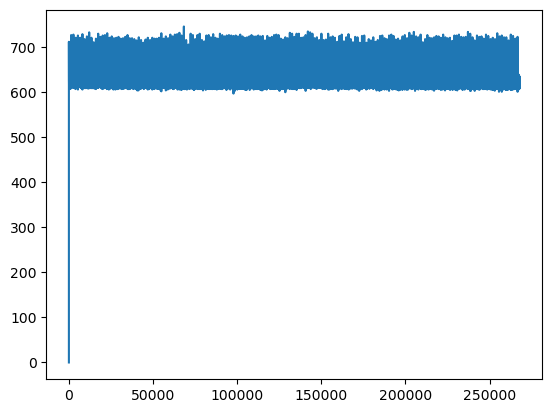

In [12]:
plt.plot(data)

In [13]:
_data = data[1:]

In [14]:
_data - data[1:]

array([0, 0, 0, ..., 0, 0, 0], dtype=uint16)

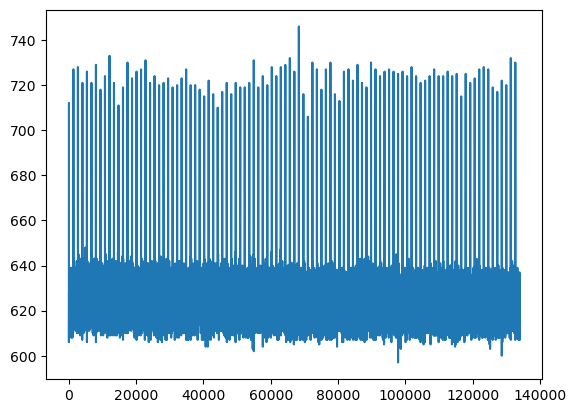

In [15]:
plt.plot(data[1:134000])

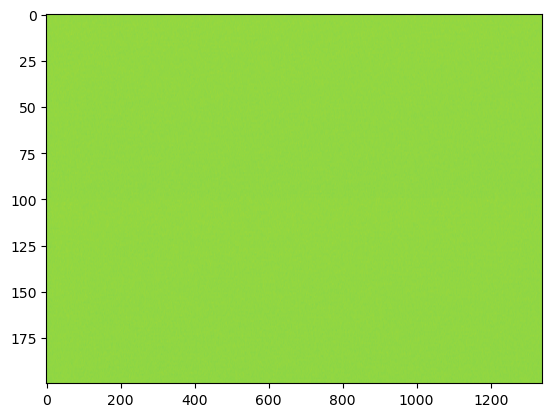

In [19]:
plt.imshow(d2d, aspect='auto')

In [ ]:
processed_frames = []
for i in range(available_data.readout_count):
    readout = readouts[i]
    frame = (c_int64 * FIXED_FRAME_SIZE).from_address(ctypes.addressof(readout.data.contents))
    dataArrayType = ctypes.c_uint16 * int(FIXED_FRAME_SIZE) #readoutstride
    dataArrayPointerType = ctypes.POINTER(dataArrayType)
    dataPointer = ctypes.cast(available_data.initial_readout, dataArrayPointerType)
    
    processed_frames.append(list(frame))  # Convert to a Python list

In [57]:
controller.close_camera()